**Extract ZIP Files**

In [ ]:
import os
import zipfile

# Define paths to the uploaded ZIP files
train_zip_path = '/content/train.zip'
test_zip_path = '/content/test.zip'
validation_zip_path = '/content/validation.zip'

# Define extraction directories
extracted_train_path = '/content/train'
extracted_test_path = '/content/test'
extracted_validation_path = '/content/validation'

# Function to extract zip files
def extract_zip(zip_path, extract_to):
    if not os.path.exists(extract_to):
        os.makedirs(extract_to)
    with zipfile.ZipFile(zip_path, 'r') as zip_ref:
        zip_ref.extractall(extract_to)
    print(f"Extracted {zip_path} to {extract_to}")

# Extract all zip files
extract_zip(train_zip_path, extracted_train_path)
extract_zip(test_zip_path, extracted_test_path)
extract_zip(validation_zip_path, extracted_validation_path)

# Check the extracted directories
print("Contents of training directory:", os.listdir(extracted_train_path)[:5])
print("Contents of testing directory:", os.listdir(extracted_test_path)[:5])
print("Contents of validation directory:", os.listdir(extracted_validation_path)[:5])


Extracted /content/train.zip to /content/train
Extracted /content/test.zip to /content/test
Extracted /content/validation.zip to /content/validation
Contents of training directory: ['train']
Contents of testing directory: ['test']
Contents of validation directory: ['validation']


**Check Directory Contents**

In [ ]:
# Check subdirectories and contents for each folder
train_subdir = os.path.join(extracted_train_path, 'train')
test_subdir = os.path.join(extracted_test_path, 'test')
validation_subdir = os.path.join(extracted_validation_path, 'validation')

def check_directory_contents(path):
    contents = os.listdir(path)
    print(f"Directory: {path}")
    print(f"Total files: {len(contents)}")
    print(f"All files: {contents}")
    return contents

train_files = check_directory_contents(train_subdir)
test_files = check_directory_contents(test_subdir)
validation_files = check_directory_contents(validation_subdir)



Directory: /content/train/train
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']
Directory: /content/test/test
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']
Directory: /content/validation/validation
Total files: 6
All files: ['angry', 'fear', 'sad', 'surprise', 'happy', 'neutral']


**Validate Image Files**

In [ ]:
from PIL import Image

def validate_images(directory):
    """
    Validates that all files in the directory are readable images.
    Returns a list of valid and invalid files.
    """
    valid_images = []
    invalid_images = []

    for root, _, files in os.walk(directory):
        for file in files:
            file_path = os.path.join(root, file)
            try:
                with Image.open(file_path) as img:
                    img.verify()  # Check if the image is valid
                valid_images.append(file_path)
            except Exception as e:
                invalid_images.append((file_path, str(e)))

    return valid_images, invalid_images

# Validate images in each directory
valid_train_images, invalid_train_images = validate_images(train_subdir)
valid_test_images, invalid_test_images = validate_images(test_subdir)
valid_validation_images, invalid_validation_images = validate_images(validation_subdir)

# Print summary
print(f"Training set: {len(valid_train_images)} valid images, {len(invalid_train_images)} invalid images.")
print(f"Testing set: {len(valid_test_images)} valid images, {len(invalid_test_images)} invalid images.")
print(f"Validation set: {len(valid_validation_images)} valid images, {len(invalid_validation_images)} invalid images.")

# If any invalid images, list the first few
if invalid_train_images:
    print("Sample invalid training images:", invalid_train_images[:5])
if invalid_test_images:
    print("Sample invalid testing images:", invalid_test_images[:5])
if invalid_validation_images:
    print("Sample invalid validation images:", invalid_validation_images[:5])


Training set: 4999 valid images, 0 invalid images.
Testing set: 750 valid images, 0 invalid images.
Validation set: 750 valid images, 0 invalid images.


**Load Image Data**

In [ ]:
import torch
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

# Define transformations for data augmentation and normalization
transform = transforms.Compose([
    transforms.Resize((64, 64)),  # Resize images to a uniform size
    transforms.ToTensor(),       # Convert images to tensors
    transforms.Normalize((0.5,), (0.5,))  # Normalize pixel values to [-1, 1]
])

# Load datasets using ImageFolder
train_dataset = datasets.ImageFolder(root=train_subdir, transform=transform)
test_dataset = datasets.ImageFolder(root=test_subdir, transform=transform)
validation_dataset = datasets.ImageFolder(root=validation_subdir, transform=transform)

# Create DataLoaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)
validation_loader = DataLoader(validation_dataset, batch_size=batch_size, shuffle=False)

# Check dataset structure
print(f"Training dataset: {len(train_dataset)} images in {len(train_dataset.classes)} classes: {train_dataset.classes}")
print(f"Testing dataset: {len(test_dataset)} images in {len(test_dataset.classes)} classes: {test_dataset.classes}")
print(f"Validation dataset: {len(validation_dataset)} images in {len(validation_dataset.classes)} classes: {validation_dataset.classes}")


Training dataset: 4999 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Testing dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']
Validation dataset: 750 images in 6 classes: ['angry', 'fear', 'happy', 'neutral', 'sad', 'surprise']


**CNN Model Training**

Epoch 1/200 - Training Accuracy: 20.68% - Validation Accuracy: 22.13%
Epoch 2/200 - Training Accuracy: 22.34% - Validation Accuracy: 21.87%
Epoch 3/200 - Training Accuracy: 23.86% - Validation Accuracy: 20.27%
Epoch 4/200 - Training Accuracy: 24.16% - Validation Accuracy: 24.67%
Epoch 5/200 - Training Accuracy: 24.32% - Validation Accuracy: 23.60%
Epoch 6/200 - Training Accuracy: 23.96% - Validation Accuracy: 22.67%
Epoch 7/200 - Training Accuracy: 25.15% - Validation Accuracy: 23.73%
Epoch 8/200 - Training Accuracy: 25.25% - Validation Accuracy: 27.07%
Epoch 9/200 - Training Accuracy: 26.07% - Validation Accuracy: 25.87%
Epoch 10/200 - Training Accuracy: 26.37% - Validation Accuracy: 27.07%
Epoch 11/200 - Training Accuracy: 26.83% - Validation Accuracy: 26.93%
Epoch 12/200 - Training Accuracy: 27.71% - Validation Accuracy: 21.33%
Epoch 13/200 - Training Accuracy: 27.53% - Validation Accuracy: 28.00%
Epoch 14/200 - Training Accuracy: 27.95% - Validation Accuracy: 26.40%
Epoch 15/200 - 

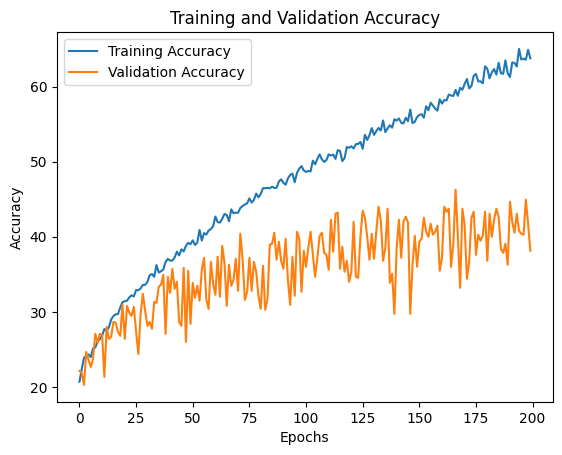

F1 Score: 0.3820
Precision: 0.4727
Recall: 0.3813


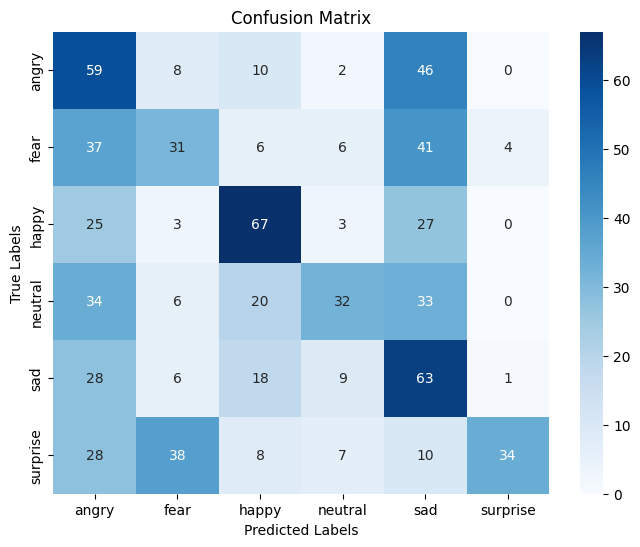

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms as transforms
from torch.utils.data import DataLoader
from torchvision import datasets
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, f1_score, precision_score, recall_score
import seaborn as sns
import numpy as np
import torch.nn.functional as F

# 1. Adding Data Augmentation
data_transforms = {
    'train': transforms.Compose([
        transforms.RandomResizedCrop(224),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(30),
        transforms.ColorJitter(brightness=0.5, contrast=0.5, saturation=0.5, hue=0.5),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize(256),
        transforms.CenterCrop(224),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ]),
}

# 2. CNN Model with Modifications
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Apply Global Average Pooling
        x = self.pool(x)
        x = torch.flatten(x, 1)  # Flatten the output for the fully connected layer

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# 3. Model Creation
num_classes = 10  # Adjust according to your class count
custom_model = CustomCNN(num_classes)

# 4. Optimizer and Loss Function
optimizer = optim.Adam(custom_model.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

# 5. Training Function with Backpropagation
def train_model_with_backprop(model, train_loader, val_loader, criterion, optimizer, num_epochs=10):
    train_accuracies = []
    val_accuracies = []

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        correct_train = 0
        total_train = 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            correct_train += (predicted == labels).sum().item()
            total_train += labels.size(0)

        train_accuracy = 100 * correct_train / total_train
        train_accuracies.append(train_accuracy)

        model.eval()
        correct_val = 0
        total_val = 0
        with torch.no_grad():
            for inputs, labels in val_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, predicted = torch.max(outputs, 1)
                correct_val += (predicted == labels).sum().item()
                total_val += labels.size(0)

        val_accuracy = 100 * correct_val / total_val
        val_accuracies.append(val_accuracy)

        print(f"Epoch {epoch+1}/{num_epochs} - Training Accuracy: {train_accuracy:.2f}% - Validation Accuracy: {val_accuracy:.2f}%")

    return train_accuracies, val_accuracies

# 6. Check Device (CUDA or CPU)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
custom_model.to(device)

# 7. Train the Model
train_accuracies, val_accuracies = train_model_with_backprop(custom_model, train_loader, validation_loader, criterion, optimizer, num_epochs=200)

# 8. Plot Training and Validation Accuracy
plt.plot(train_accuracies, label='Training Accuracy')
plt.plot(val_accuracies, label='Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.title('Training and Validation Accuracy')
plt.show()

# Confusion Matrix and F1-Score Plotting Function
def plot_confusion_matrix_and_metrics(model, dataloader, classes, device):
    model.eval()
    all_preds = []
    all_labels = []

    with torch.no_grad():
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)
            all_preds.extend(predicted.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())

    cm = confusion_matrix(all_labels, all_preds)
    f1 = f1_score(all_labels, all_preds, average='weighted')
    precision = precision_score(all_labels, all_preds, average='weighted')
    recall = recall_score(all_labels, all_preds, average='weighted')

    print(f'F1 Score: {f1:.4f}')
    print(f'Precision: {precision:.4f}')
    print(f'Recall: {recall:.4f}')

    plt.figure(figsize=(8, 6))
    sns.heatmap(cm, annot=True, fmt='g', cmap='Blues', xticklabels=classes, yticklabels=classes)
    plt.title('Confusion Matrix')
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.show()

# Plot Confusion Matrix and Calculate F1-Score
plot_confusion_matrix_and_metrics(custom_model, validation_loader, train_loader.dataset.classes, device)


**Image Prediction Display**

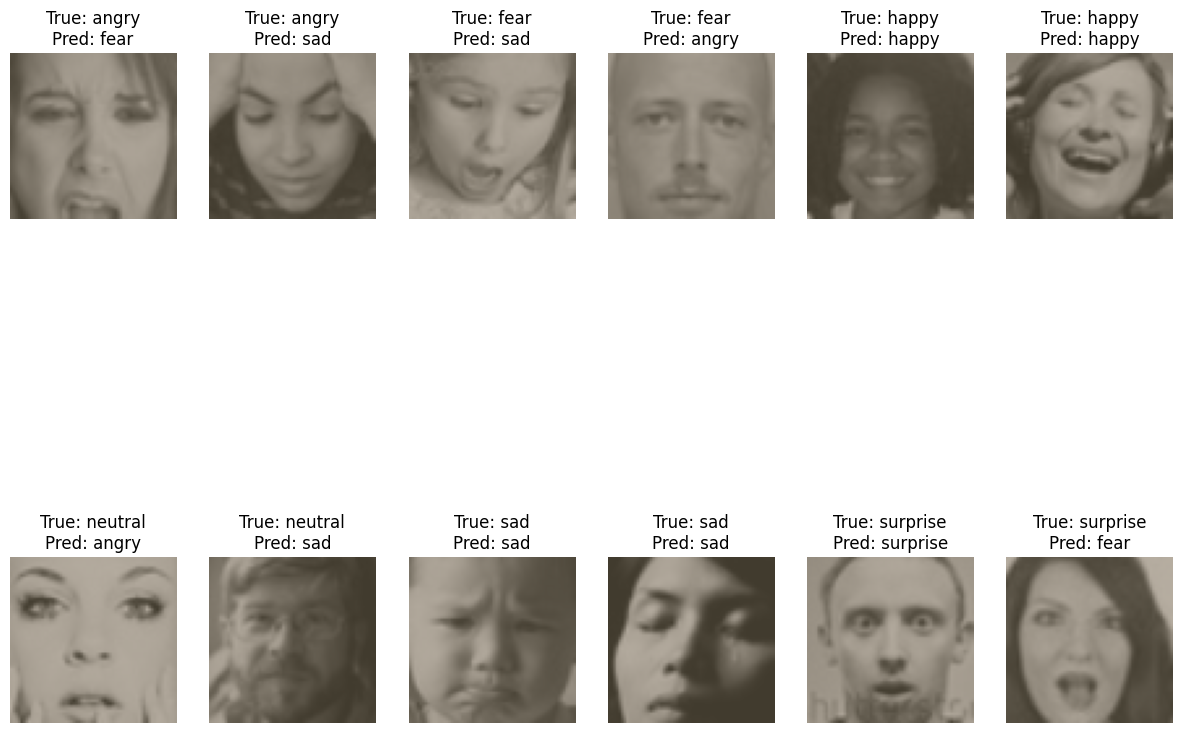

In [ ]:
import matplotlib.pyplot as plt
import torch
import numpy as np
from torch.utils.data import DataLoader
from torchvision import datasets

# Function to display 12 random images from each class with true labels and predictions
def show_images_with_predictions_per_class(model, dataloader, class_names, device, num_images_per_class=2):
    model.eval()

    # Store images and labels to be displayed
    images_to_show = []
    labels_to_show = []

    # Collect images from each class
    for class_idx, class_name in enumerate(class_names):
        # Filter data to get images belonging to the current class
        class_images = []
        class_labels = []

        for inputs, labels in dataloader:
            mask = labels == class_idx  # Select images belonging to the current class
            inputs, labels = inputs[mask].to(device), labels[mask].to(device)
            class_images.append(inputs)
            class_labels.append(labels)

        # Select num_images_per_class random images from this class
        if class_images:
            class_images = torch.cat(class_images, dim=0)
            class_labels = torch.cat(class_labels, dim=0)
            idx = torch.randperm(class_images.size(0))[:num_images_per_class]
            images_to_show.extend(class_images[idx])
            labels_to_show.extend(class_labels[idx])

    images_to_show = torch.stack(images_to_show)
    labels_to_show = torch.tensor(labels_to_show)

    # Get predictions
    with torch.no_grad():
        outputs = model(images_to_show)
        _, predicted = torch.max(outputs, 1)

    # Display images with true labels and predictions
    fig = plt.figure(figsize=(15, 12))

    for i in range(len(images_to_show)):
        ax = fig.add_subplot(2, 6, i + 1)  # 2 rows and 6 columns
        img = images_to_show[i].cpu().numpy().transpose((1, 2, 0))  # Reorder dimensions for display
        img = np.clip(img * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406]), 0, 1)  # Normalize the image
        ax.imshow(img)

        # Add true and predicted labels
        true_label = class_names[labels_to_show[i]]
        predicted_label = class_names[predicted[i]]
        ax.set_title(f'True: {true_label}\nPred: {predicted_label}')
        ax.axis('off')

    plt.show()

# Display 2 random images from each class with predictions (total of 12 images)
show_images_with_predictions_per_class(custom_model, validation_loader, train_loader.dataset.classes, device, num_images_per_class=2)


**Model Accuracy Evaluation**

In [ ]:
def calculate_accuracy(model, dataloader, device):
    model.eval()  # Set model to evaluation mode
    correct = 0
    total = 0

    with torch.no_grad():  # Disable gradient calculations for backpropagation
        for inputs, labels in dataloader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            _, predicted = torch.max(outputs, 1)  # Get the predicted class
            correct += (predicted == labels).sum().item()  # Count correct predictions
            total += labels.size(0)  # Total number of samples

    accuracy = 100 * correct / total  # Calculate accuracy
    return accuracy

# After training, calculate accuracy for train, validation, and test sets
train_accuracy = calculate_accuracy(custom_model, train_loader, device)
val_accuracy = calculate_accuracy(custom_model, validation_loader, device)
test_accuracy = calculate_accuracy(custom_model, test_loader, device)

# Display the results
print(f"Training Accuracy: {train_accuracy:.2f}%")
print(f"Validation Accuracy: {val_accuracy:.2f}%")
print(f"Test Accuracy: {test_accuracy:.2f}%")


Training Accuracy: 57.77%
Validation Accuracy: 38.13%
Test Accuracy: 38.53%


**Save Model Weights**

In [ ]:
import torch



# Save model weights
def save_model_weights(model, file_name='model_weights.pth'):
    torch.save(model.state_dict(), file_name)
    print(f'Weights saved to {file_name}')

# Assume the model has been trained, you can save its weights after training
save_model_weights(custom_model, 'custom_model_weights.pth')


Weights saved to custom_model_weights.pth


**Image Classification with CNN**

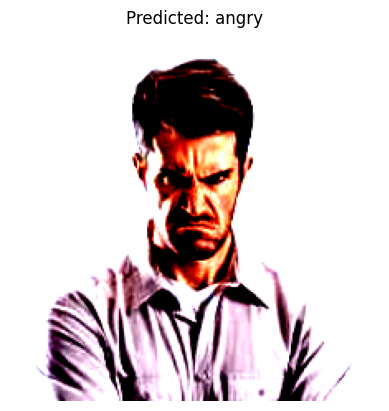

The predicted class for /content/download (1).jpg is: angry


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import torchvision.transforms as transforms
import matplotlib.pyplot as plt
from PIL import Image
import os
import numpy as np

# Define transformations for image preprocessing
transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
])

# Define Custom CNN model
class CustomCNN(nn.Module):
    def __init__(self, num_classes):
        super(CustomCNN, self).__init__()

        self.conv1 = nn.Conv2d(in_channels=3, out_channels=32, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(32)

        self.conv2 = nn.Conv2d(in_channels=32, out_channels=64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)

        self.conv3 = nn.Conv2d(in_channels=64, out_channels=128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)

        self.pool = nn.AdaptiveAvgPool2d(1)  # Global Average Pooling

        self.fc1 = nn.Linear(128, 512)
        self.fc2 = nn.Linear(512, num_classes)
        self.dropout = nn.Dropout(p=0.5)

    def forward(self, x):
        x = F.relu(self.bn1(self.conv1(x)))
        x = F.relu(self.bn2(self.conv2(x)))
        x = F.relu(self.bn3(self.conv3(x)))

        # Apply Global Average Pooling
        x = self.pool(x)
        x = torch.flatten(x, 1)  # Flatten the output for the fully connected layer

        x = F.relu(self.fc1(x))
        x = self.dropout(x)
        x = self.fc2(x)
        return x

# Instantiate the model
num_classes = 6  # Adjust according to your class count
model = CustomCNN(num_classes)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

# Define the function to predict the class for a single image
def predict_single_image(image_path, model, transform, class_names):
    predictions = {}

    # Load image
    image = Image.open(image_path).convert('RGB')

    # Apply transformations
    image = transform(image).unsqueeze(0)  # Add batch dimension

    # Move the image to the same device as the model
    image = image.to(device)

    # Set the model to evaluation mode
    model.eval()

    # Make the prediction
    with torch.no_grad():
        outputs = model(image)
        _, predicted = torch.max(outputs, 1)

    # Get the predicted class name
    predicted_class = class_names[predicted.item()]

    # Display the image with its predicted class
    plt.imshow(image.squeeze(0).cpu().numpy().transpose(1, 2, 0))  # Remove batch dimension and denormalize
    plt.title(f"Predicted: {predicted_class}")
    plt.axis('off')
    plt.show()

    # Store the predicted class
    predictions[image_path] = predicted_class

    return predictions

# Example usage of the predict_single_image function
class_names = ['fear', 'neutral', 'sad', 'surprise', 'happy', 'angry']  # Emotion classes
image_path = '/content/download (1).jpg'  # Specify the image path

predictions = predict_single_image(image_path, model, transform, class_names)
for image_path, predicted_class in predictions.items():
    print(f"The predicted class for {image_path} is: {predicted_class}")
